In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir /content/Inputs

In [3]:
!pip install -q torch torchvision
!pip install -q opencv-python

In [4]:
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2
!pip install -e .

Cloning into 'detectron2'...
remote: Enumerating objects: 15943, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 15943 (delta 4), reused 3 (delta 3), pack-reused 15930 (from 2)
Receiving objects: 100% (15943/15943), 6.70 MiB | 12.01 MiB/s, done.
Resolving deltas: 100% (11336/11336), done.
/content/detectron2
Obtaining file:///content/detectron2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 32.5 MB/s eta 0:00:00
  Created wheel for fvcore

In [5]:
%cd projects/DensePose
!pip install -e .
%cd ../../

/content/detectron2/projects/DensePose
Obtaining file:///content/detectron2/projects/DensePose
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-install-9qm0s6e2/detectron2_5156f33953304cb09532d23cb2954046
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-install-9qm0s6e2/detectron2_5156f33953304cb09532d23cb2954046
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 23.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111612 sha256=afbc28f06ad0a4634f8ef182910045477ea03e290f9109a9d0e399a777dd6219
  Stored in directory: /tmp/pip-ephem-wheel-cache-ivq9pb_v/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
Successfully built detect

In [6]:
!pip list | grep detectron2

detectron2                               0.6
detectron2-densepose                     0.6                 /content/detectron2/projects/DensePose


In [7]:
import torch
print("CUDA:", torch.cuda.is_available())
import detectron2
print("Detectron2 OK")

CUDA: True
Detectron2 OK


In [8]:
import sys
sys.path.append("/content/detectron2/projects/DensePose")

from densepose import add_densepose_config
print("DensePose OK")

DensePose OK


In [9]:
import cv2
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from densepose import add_densepose_config
import os

IMAGE_PATH = "/content/Inputs/00006_00.jpg"
OUTPUT_PATH = "/content/drive/MyDrive/virtual_tryon_project/virtual-tryon/outputs/densepose/00006_00.png"

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Config
cfg = get_cfg()
add_densepose_config(cfg)
cfg.merge_from_file(
    "/content/detectron2/projects/DensePose/configs/densepose_rcnn_R_50_FPN_s1x.yaml"
)

cfg.MODEL.WEIGHTS = (
    "https://dl.fbaipublicfiles.com/densepose/"
    "densepose_rcnn_R_50_FPN_s1x/165712039/model_final_162be9.pkl"
)

cfg.MODEL.DEVICE = "cuda"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

predictor = DefaultPredictor(cfg)

image = cv2.imread(IMAGE_PATH)
outputs = predictor(image)

instances = outputs["instances"].to("cpu")

if len(instances) == 0:
    raise ValueError("No person detected")

dp = instances.pred_densepose
boxes = instances.pred_boxes.tensor.numpy()

dp_output = dp[0]

# -----------------------------
# Extract fine segmentation (24 parts)
# -----------------------------
fine = dp_output.fine_segm.cpu().numpy()

print("fine shape:", fine.shape)

# fine shape: (1, 24, H, W)
fine = fine[0]

# Convert probabilities to part IDs (0–24)
segm = np.argmax(fine, axis=0).astype(np.uint8)

bbox = boxes[0].astype(int)

# -----------------------------
# Reconstruct full image
# -----------------------------
H, W = image.shape[:2]
full_segm = np.zeros((H, W), dtype=np.uint8)

x1, y1, x2, y2 = bbox
w_box = x2 - x1
h_box = y2 - y1

segm_resized = cv2.resize(
    segm,
    (w_box, h_box),
    interpolation=cv2.INTER_NEAREST
)

full_segm[y1:y2, x1:x2] = segm_resized

cv2.imwrite(OUTPUT_PATH, full_segm)

print("Saved:", OUTPUT_PATH)
print("Unique Body Part IDs:", np.unique(full_segm))

model_final_162be9.pkl: 256MB [00:00, 269MB/s]                           
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0225 13:03:43.875000 2176 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


fine shape: (1, 25, 112, 112)
Saved: /content/drive/MyDrive/virtual_tryon_project/virtual-tryon/outputs/densepose/00006_00.png
Unique Body Part IDs: [ 0  2  3  4  5  6  9 10 15 16 17 18 19 20 21 22 23 24]


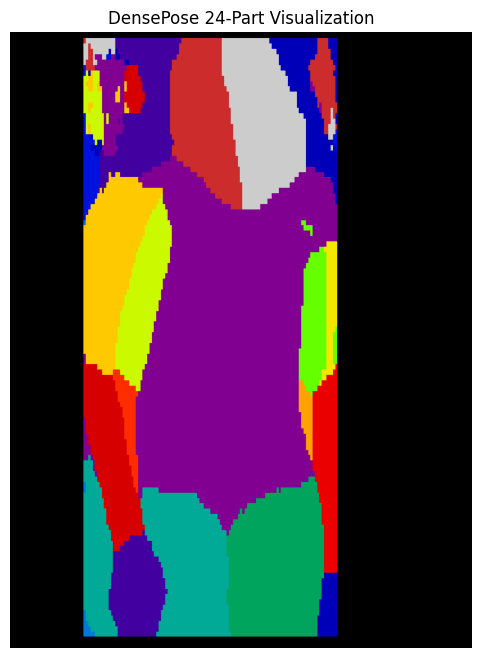

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

densepose_path = "/content/drive/MyDrive/virtual_tryon_project/virtual-tryon/outputs/densepose/00006_00.png"

label_map = cv2.imread(densepose_path, 0)

# Use consistent colormap
colored = plt.cm.nipy_spectral(label_map / 24.0)

# Convert to 0–255 RGB
colored = (colored[:, :, :3] * 255).astype(np.uint8)

plt.figure(figsize=(6,8))
plt.imshow(colored)
plt.title("DensePose 24-Part Visualization")
plt.axis("off")
plt.show()


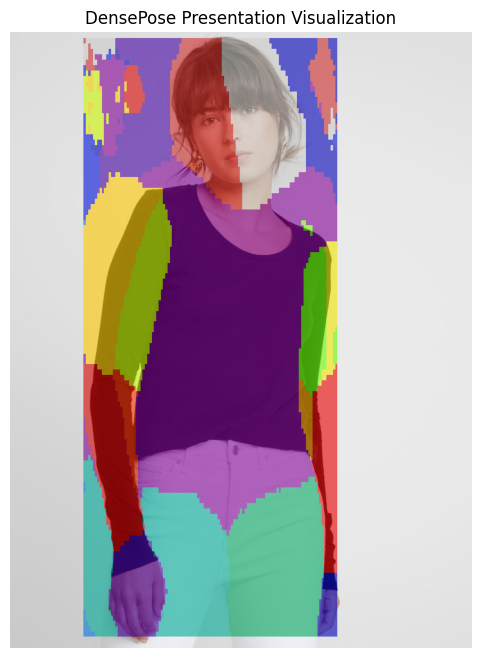

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

densepose_path = "/content/drive/MyDrive/virtual_tryon_project/virtual-tryon/outputs/densepose/00006_00.png"
image_path = "/content/Inputs/00006_00.jpg"

label_map = cv2.imread(densepose_path, 0)
original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Resize label map smoothly to original resolution
smooth_map = cv2.resize(
    label_map,
    (original.shape[1], original.shape[0]),
    interpolation=cv2.INTER_LINEAR
)

# Apply color map
colored = plt.cm.nipy_spectral(smooth_map / 24.0)
colored = (colored[:, :, :3] * 255).astype(np.uint8)

# Create mask from resized map
mask = smooth_map > 0

# Blend for smooth visualization
alpha = 0.6
overlay = original.copy()
overlay[mask] = (
    alpha * colored[mask] +
    (1 - alpha) * original[mask]
).astype(np.uint8)

plt.figure(figsize=(6,8))
plt.imshow(overlay)
plt.axis("off")
plt.title("DensePose Presentation Visualization")
plt.show()

use cli method to run densepose

In [12]:
%cd /content/detectron2/projects/DensePose

!python apply_net.py dump configs/densepose_rcnn_R_50_FPN_s1x.yaml \
https://dl.fbaipublicfiles.com/densepose/densepose_rcnn_R_50_FPN_s1x/165712039/model_final_162be9.pkl \
/content/Inputs/00006_00.jpg \
--output /content/drive/MyDrive/virtual_tryon_project/virtual-tryon/outputs/densepose/00006_00_dump.pkl \
--opts MODEL.DEVICE cuda

/content/detectron2/projects/DensePose
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0225 13:03:52.510000 5879 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Unique IDs: [ 0  2  3  4  9 10 15 16 17 18 19 20 21 22 23 24]


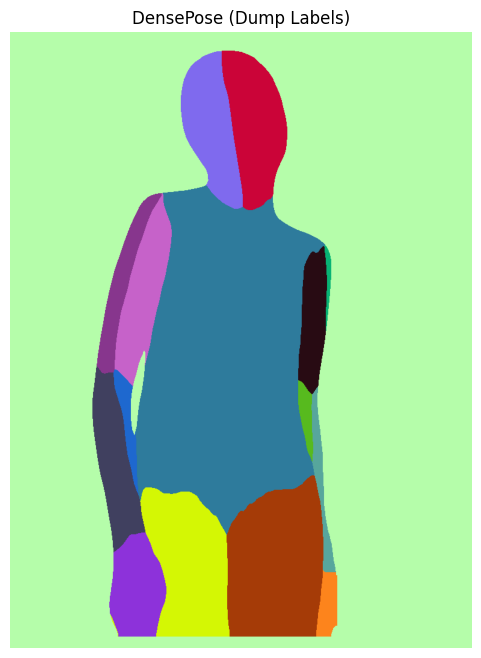

In [13]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

PKL_PATH = "/content/drive/MyDrive/virtual_tryon_project/virtual-tryon/outputs/densepose/00006_00_dump.pkl"
IMAGE_PATH = "/content/Inputs/00006_00.jpg"

data = torch.load(PKL_PATH, weights_only=False)
prediction = data[0]

boxes = prediction["pred_boxes_XYXY"]
dp_outputs = prediction["pred_densepose"]

image = cv2.imread(IMAGE_PATH)
H, W = image.shape[:2]

# First detected person
bbox = boxes[0]
x1, y1, x2, y2 = map(int, bbox)
w_box = x2 - x1
h_box = y2 - y1

dp_output = dp_outputs[0]

# THIS is the correct field
labels = dp_output.labels.cpu().numpy()  # (112,112)

# Resize labels directly (this is what CLI uses)
segm_resized = cv2.resize(
    labels.astype(np.uint8),
    (w_box, h_box),
    interpolation=cv2.INTER_NEAREST
)

# Place into full image
full_segm = np.zeros((H, W), dtype=np.uint8)
full_segm[y1:y2, x1:x2] = segm_resized

print("Unique IDs:", np.unique(full_segm))

# Visualize like VITON-HD
palette = np.random.randint(0, 255, (25, 3), dtype=np.uint8)
vis = palette[full_segm]

plt.figure(figsize=(6,8))
plt.imshow(vis)
plt.axis("off")
plt.title("DensePose (Dump Labels)")
plt.show()